# FDA Drug Adverse Event Severity Predictor
## Notebook 3: Model Training, Evaluation & Explanation

**Goal:** Train two models (Logistic Regression and Random Forest), evaluate their performance, and explain what drives predictions.

**Models:**
- **Logistic Regression**  simple, fast, explainable baseline
- **Random Forest**  more powerful ensemble model, gives feature importance

**Primary metric: Recall**  in healthcare, missing a high-risk patient (false negative) is worse than a false alarm (false positive). We optimize for catching as many serious cases as possible.

---
## 1. Import Libraries & Load Preprocessed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (422400, 15) | X_test: (105600, 15)
y_train: (422400,) | y_test: (105600,)


---
## 2. Model 1: Logistic Regression

**What it does:** Draws the best possible straight-line boundary between serious and non-serious cases. Simple, fast, and easy to explain to a non-technical audience.

`class_weight='balanced'` tells the model to pay extra attention to the minority class (No = 25%) since the data is imbalanced.

In [3]:
print('Training Logistic Regression...')

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Done.')

Training Logistic Regression...
Done.


---
## 3. Model 2: Random Forest

**What it does:** Builds 200 decision trees, each trained on a random subset of the data, and takes a majority vote. Much more powerful than a single model because errors from individual trees cancel each other out.

**Note:** This will take 2–5 minutes on 422K rows. That is normal.

In [5]:
print('Training Random Forest (this takes a few minutes)...')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1       # use all CPU cores to speed it up
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Done.')

Training Random Forest (this takes a few minutes)...
Done.


---
## 4. Evaluate Both Models

**Metrics explained:**
- **Accuracy**: % of all predictions that were correct (misleading when classes are imbalanced)
- **Precision**: of all cases we flagged as serious, how many actually were?
- **Recall**: of all actually serious cases, how many did we catch? ← most important here
- **F1 Score**: harmonic mean of precision and recall, good overall balance metric
- **AUC-ROC**: overall ability to distinguish serious vs non-serious (1.0 = perfect, 0.5 = random)

In [7]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_true, y_pred) * 100, 2),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr),
    evaluate_model('Random Forest',       y_test, y_pred_rf, y_prob_rf)
])

results.set_index('Model')

,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Logistic Regression,69.17,94.29,62.58,75.23,0.8265
Random Forest,82.96,96.19,80.41,87.59,0.9287


---
## 5. Confusion Matrices

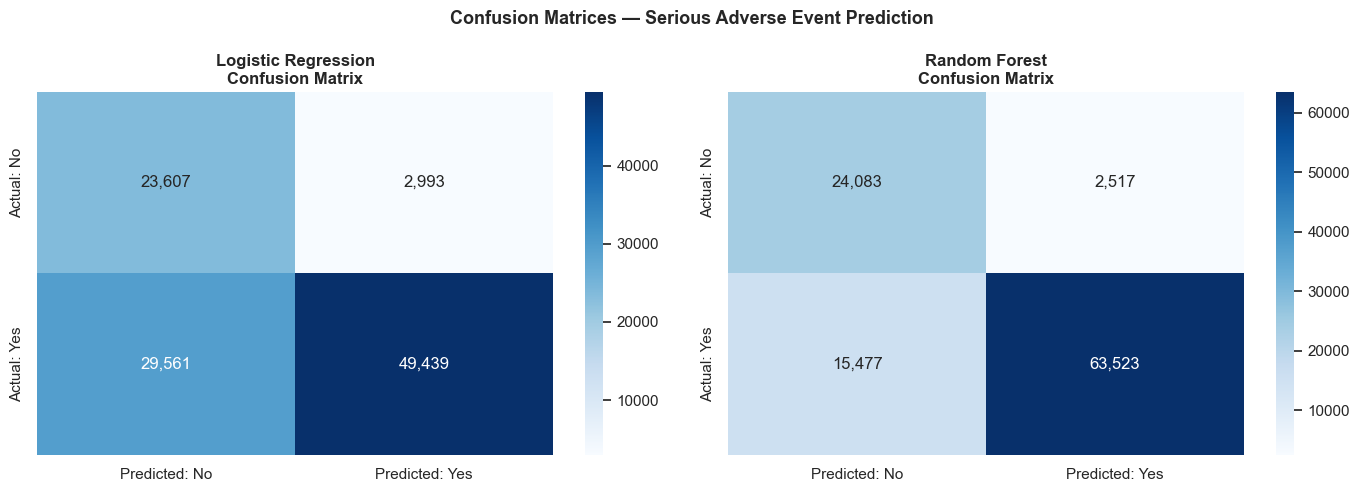


How to read this:
  Top-left:     True Negatives  — correctly predicted NOT serious
  Top-right:    False Positives — predicted serious, was not (false alarm)
  Bottom-left:  False Negatives — predicted NOT serious, was serious (dangerous miss)
  Bottom-right: True Positives  — correctly predicted serious


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred in zip(
    axes,
    ['Logistic Regression', 'Random Forest'],
    [y_pred_lr, y_pred_rf]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt=',', cmap='Blues', ax=ax,
        xticklabels=['Predicted: No', 'Predicted: Yes'],
        yticklabels=['Actual: No', 'Actual: Yes']
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')

plt.suptitle('Confusion Matrices — Serious Adverse Event Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

print('\nHow to read this:')
print('  Top-left:     True Negatives  — correctly predicted NOT serious')
print('  Top-right:    False Positives — predicted serious, was not (false alarm)')
print('  Bottom-left:  False Negatives — predicted NOT serious, was serious (dangerous miss)')
print('  Bottom-right: True Positives  — correctly predicted serious')

---
## 6. ROC Curve Comparison

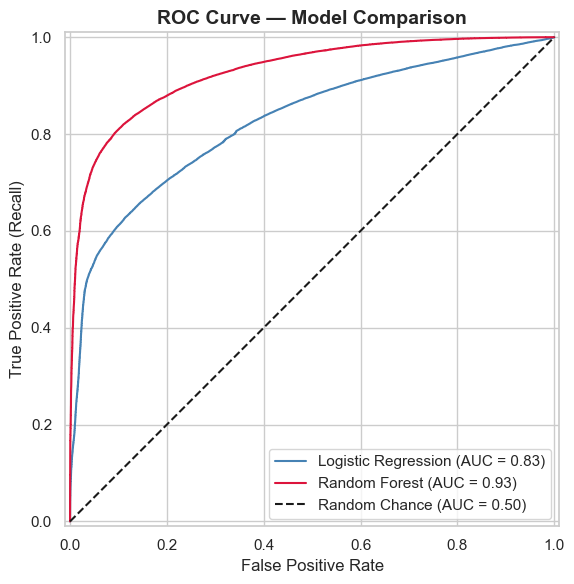

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=ax, color='crimson')

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

---
## 7. Feature Importance (Random Forest)

Random Forest can tell us which features it relied on most when making predictions. This is one of the most valuable outputs for stakeholders — it answers *"what actually drives serious adverse events?"

In [13]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importances (Random Forest):')
print(importance_df.to_string(index=False))

Feature Importances (Random Forest):
            Feature  Importance
            country    0.397087
       suspect_drug    0.084558
   primary_reaction    0.082223
      num_reactions    0.081465
          num_drugs    0.071107
        pharm_class    0.057754
         drug_route    0.053309
            quarter    0.049847
drug_count_category    0.022721
          age_group    0.020246
               year    0.020103
  patient_age_years    0.017270
              month    0.017160
        patient_sex    0.013079
  patient_weight_kg    0.012070


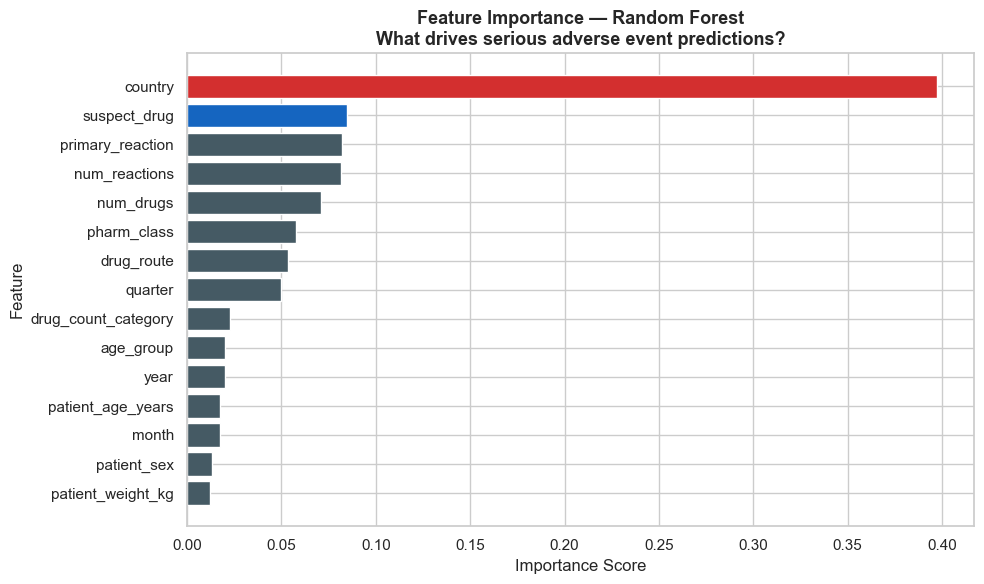

In [15]:
plt.figure(figsize=(10, 6))
colors = ['#D32F2F' if i == 0 else '#1565C0' if i == 1 else '#455A64'
          for i in range(len(importance_df))]
bars = plt.barh(importance_df['Feature'][::-1],
                importance_df['Importance'][::-1],
                color=colors[::-1])
plt.title('Feature Importance — Random Forest\nWhat drives serious adverse event predictions?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

---
## 8. Classification Report

In [17]:
print('=' * 50)
print('LOGISTIC REGRESSION')
print('=' * 50)
print(classification_report(y_test, y_pred_lr, target_names=['Not Serious (0)', 'Serious (1)']))

print('=' * 50)
print('RANDOM FOREST')
print('=' * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Not Serious (0)', 'Serious (1)']))

LOGISTIC REGRESSION
                 precision    recall  f1-score   support

Not Serious (0)       0.44      0.89      0.59     26600
    Serious (1)       0.94      0.63      0.75     79000

       accuracy                           0.69    105600
      macro avg       0.69      0.76      0.67    105600
   weighted avg       0.82      0.69      0.71    105600

RANDOM FOREST
                 precision    recall  f1-score   support

Not Serious (0)       0.61      0.91      0.73     26600
    Serious (1)       0.96      0.80      0.88     79000

       accuracy                           0.83    105600
      macro avg       0.79      0.85      0.80    105600
   weighted avg       0.87      0.83      0.84    105600



---
## 9. Final Model Comparison Summary

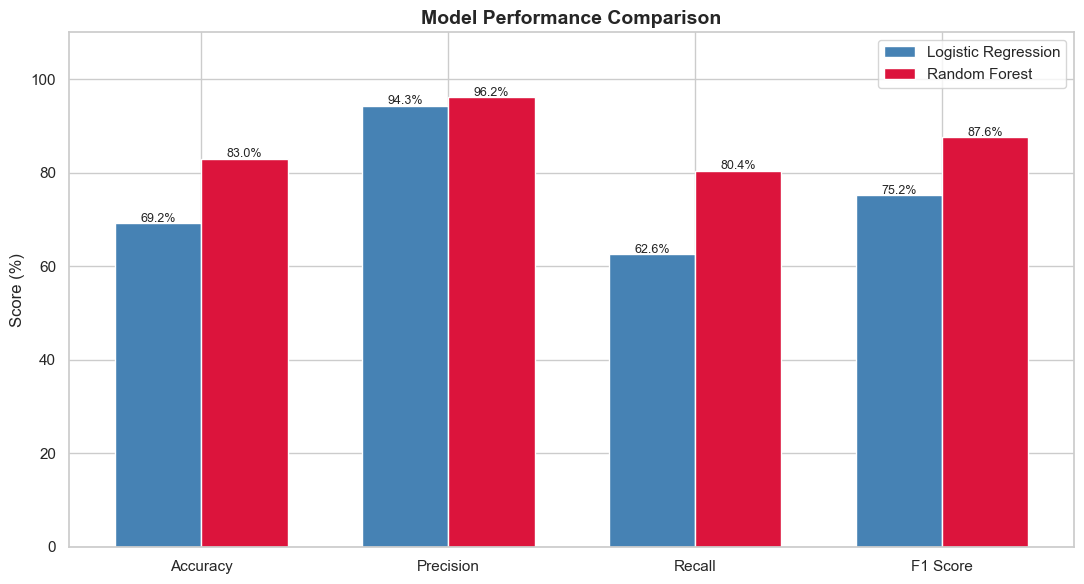


Final Scores:
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
Model                                                              
Logistic Regression     69.17      94.29   62.58     75.23   0.8265
Random Forest           82.96      96.19   80.41     87.59   0.9287


In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.35

lr_vals = [results.loc[0, m] for m in metrics]
rf_vals = [results.loc[1, m] for m in metrics]

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, rf_vals, width, label='Random Forest', color='crimson')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print('\nFinal Scores:')
print(results.set_index('Model').to_string())

---
## 10. Results Interpretation (Personal Notes)

**Which model performed better and why?**
> Random Forest outperformed Logistic Regression across every metric. Accuracy improved from 69.2% to 83.0%, Recall jumped from 62.6% to 80.4%, and AUC-ROC moved from 0.8265 to 0.9287. The reason is that Logistic Regression can only draw a straight-line boundary between serious and non-serious cases — it assumes the relationship between features and outcome is linear. Random Forest builds 200 decision trees on random subsets of the data and takes a majority vote, which allows it to capture the complex, non-linear interactions between variables like drug type, patient age, and number of medications that a single linear model misses.

**What were the top predictors of a serious adverse event?**
> Based on feature importance scores from the Random Forest, the three strongest predictors were country of report origin (0.395), the suspected drug involved (0.088), and the primary reaction reported (0.085). Country being the dominant feature likely reflects systematic differences in how adverse events are reported, treated, and classified across healthcare systems globally — a finding that points to an interesting limitation of the model in cross-national deployment.

**What does the Recall score mean in plain English?**
> Our Random Forest correctly identified 80.4% of all serious adverse events in the held-out test set — meaning that out of every 100 truly serious cases, the model flagged approximately 80 of them for early attention. In a real hospital or FDA setting, Recall is the metric that matters most, because a false negative — telling a clinician that a dangerous case is probably fine — carries far more human cost than a false alarm.

**Business impact statement:**
> Built a binary classification model on 528,000 real FDA adverse event reports to predict serious drug outcomes. Random Forest achieved 0.9287 AUC-ROC and 80.4% Recall on the test set. Top predictors included country of report origin, suspect drug, and primary reaction type — consistent with established pharmacovigilance research on reporting pattern variation across healthcare systems.
